# Algorithm Comparison: LMS vs. CBP+Autostep on Feature Sifting

Hyperparameter sweeps for **LMS** (learning-rate grid) and **CBP+Autostep** (one-at-a-time
sensitivity sweep over `learning_rate`, `meta_learning_rate`, `replace_rate`), under two
scenarios, each followed by a 30-seed run of the best configuration found:

- **01 — Stationary** (`task.flip_period = -1`): the target function never changes.
- **02 — Non-stationary** (`task.flip_period = 100`): one target weight flips sign every 100 steps.

Each sweep family is versioned (`<base>_v<n>`); we automatically use the *final* (highest-numbered)
version present for each method/scenario — see the printed `Using sweeps:` line below.

**Seeds & confidence intervals.** Seeds are *vmapped inside* a single run, so each run logs
the **mean** `loss` over its seed set (plus `loss_std`, the std across seeds). The sweeps use
5 seeds and the best-config follow-ups use 30 seeds. Per the request, **only the 30-seed
best-config curves carry confidence intervals** (95% CI of the mean, reconstructed from the
logged `loss_std`). The 5-seed sweep plots show point/mean values without CIs.

**NaN policy.** We do **not** omit NaNs (`nan_policy='propagate'`). Because seeds are vmapped,
a single diverged seed already makes that run's mean `loss` NaN — i.e. one NaN poisons the
whole seed set. Such points are left as gaps so divergence is visible (e.g. LMS at large
step-sizes in the non-stationary scenario).

In [ ]:
# # Run once to fetch from MLflow; comment out afterwards to use the cached CSVs in data/.
# from phd.research_utils.scripts.mlflow_download import download_experiment

# download_experiment('feature_sifting_sweeps', output_dir='data')
# download_experiment('feature_sifting_best', output_dir='data')

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:phd.research_utils.scripts.mlflow_download:Tracking URI: postgresql:///mlflow?host=/var/run/postgresql&port=5433
INFO:phd.research_utils.scripts.mlflow_download:Found experiment 'feature_sifting_sweeps' (id=37)
INFO:phd.research_utils.scripts.mlflow_download:Found 136 runs
INFO:phd.research_utils.scripts.mlflow_download:Discovered 10 metric names from 10 sample runs
INFO:phd.research_utils.scripts.mlflow_download:Metrics to download: ['average_loss', 'best_possible_noise', 'final_loss', 'generated_best_frac', 'loss', 'loss_std', 'n_generated', 'n_pruned', 'normalized_loss', 'pruned_best_frac']
Downloading: 100%|██████████| 136/136 [00:14<00:00,  9.11it/s]
INFO:phd.research_utils.scripts.mlflow_download:Saved 136 param ro

In [2]:
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

set_matplotlib_style('default')
%matplotlib inline

# Shared palette: CBP+Autostep -> blue, LMS -> red.
METHOD_ORDER = ['CBP', 'LMS']
PALETTE = get_color_palette(classes=METHOD_ORDER)
PALETTE

{'CBP': '#0086DA', 'LMS': '#CA3720'}

In [3]:
sweep_cfg, sweep_run = load_experiment_data(
    'data/feature_sifting_sweeps_params.csv',
    'data/feature_sifting_sweeps_metrics.csv',
)
best_cfg, best_run = load_experiment_data(
    'data/feature_sifting_best_params.csv',
    'data/feature_sifting_best_metrics.csv',
)

# Drop the step-0 summary rows (final_loss / average_loss logged with no step); the real
# per-step series starts at step = log_freq. This leaves only genuine learning-curve points.
def drop_summary_rows(run_dfs):
    for k, rdf in run_dfs.items():
        run_dfs[k] = rdf[rdf['step'] > 0].copy()

drop_summary_rows(sweep_run)
drop_summary_rows(best_run)

print('Sweep buckets:', {k: len(v) for k, v in sweep_cfg.items()})
print('Best buckets :', {k: len(v) for k, v in best_cfg.items()})

Sweep buckets: {'cbp_autostep_ns_v5': 14, 'cbp_autostep_ns_v4': 12, 'lms_ns_v1': 15, 'cbp_autostep_ns_v3': 11, 'cbp_autostep_ns_v2': 12, 'cbp_autostep_ns_v1': 13, 'cbp_autostep_v2': 13, 'cbp_autostep_v1': 24, 'lms_v1': 7}
Best buckets : {'lms_ns': 1, 'lms': 1, 'cbp_autostep': 1, 'cbp_autostep_ns': 1}


In [4]:
import re

# --- Sweep names (final = highest-numbered version present) --------------------------------
# Each sweep family is named "<base>_v<n>"; we auto-select the latest n so re-running a sweep
# (e.g. cbp_autostep_ns_v5 superseding v4) is picked up without editing this cell.
def latest_sweep(pattern):
    rx = re.compile(pattern)
    cands = [(int(rx.match(k).group(1)), k) for k in sweep_cfg if rx.match(k)]
    if not cands:
        raise KeyError(f'no sweep matching {pattern!r}')
    return max(cands)[1]

SWEEPS = {
    '01': {'lms': latest_sweep(r'^lms_v(\d+)$'),
           'cbp': latest_sweep(r'^cbp_autostep_v(\d+)$')},      # stationary
    '02': {'lms': latest_sweep(r'^lms_ns_v(\d+)$'),
           'cbp': latest_sweep(r'^cbp_autostep_ns_v(\d+)$')},   # non-stationary
}
print('Using sweeps:', SWEEPS)
BEST = {
    '01': {'LMS': 'lms',    'CBP': 'cbp_autostep'},
    '02': {'LMS': 'lms_ns', 'CBP': 'cbp_autostep_ns'},
}
SCEN_LABEL = {'01': 'stationary', '02': 'non-stationary'}

LR, META_LR, RR = (
    'method.hparams.learning_rate',
    'method.hparams.meta_learning_rate',
    'method.hparams.replace_rate',
)
CBP_PARAMS = [LR, META_LR, RR]
PARAM_LABELS = {LR: 'Learning rate', META_LR: 'Meta learning rate', RR: 'Replace rate'}


def prep_cfg(cfg):
    """Return a copy with hyperparameter columns coerced to numeric."""
    cfg = cfg.copy()
    for c in CBP_PARAMS:
        if c in cfg.columns:
            cfg[c] = pd.to_numeric(cfg[c], errors='coerce')
    return cfg


def baseline_of(cfg, params):
    """Baseline value of each swept param = its mode (the sensitivity sweep holds every
    other param at this baseline while one varies, so the baseline is the most common value)."""
    return {p: cfg[p].mode().iloc[0] for p in params if p in cfg.columns}


def hold_others(scenario, vary):
    """CBP runs for `scenario` with every param except `vary` pinned to its baseline."""
    sw = SWEEPS[scenario]['cbp']
    cfg, run = prep_cfg(sweep_cfg[sw]), sweep_run[sw]
    base = baseline_of(cfg, CBP_PARAMS)
    chosen = {p: v for p, v in base.items() if p != vary}
    return select_experiment_runs(run, cfg, chosen)


def apply_logy(ylim=None):
    """Switch the current figure's axes to a log y-scale, refitting limits to the positive
    line data (matplotlib leaves a stale linear ylim otherwise)."""
    for ax in plt.gcf().axes:
        ax.set_yscale('log')
        if ylim is not None:
            ax.set_ylim(*ylim)
        elif ax.get_lines():
            ys = np.concatenate([ln.get_ydata() for ln in ax.get_lines()])
            ys = ys[np.isfinite(ys) & (ys > 0)]
            if ys.size:
                ax.set_ylim(ys.min() / 1.5, ys.max() * 1.5)

Using sweeps: {'01': {'lms': 'lms_v1', 'cbp': 'cbp_autostep_v2'}, '02': {'lms': 'lms_ns_v1', 'cbp': 'cbp_autostep_ns_v5'}}


In [5]:
def lr_sensitivity(scenario, metric_col='loss', logy=True):
    """Learning-rate sensitivity, comparing LMS and CBP on one axis (CBP's other params
    held at baseline). 5 seeds -> no CI. NaNs propagate (gaps)."""
    lms_sw, cbp_sw = SWEEPS[scenario]['lms'], SWEEPS[scenario]['cbp']
    lcfg, lrun = prep_cfg(sweep_cfg[lms_sw]), sweep_run[lms_sw]
    ccfg = prep_cfg(sweep_cfg[cbp_sw])
    base = baseline_of(ccfg, CBP_PARAMS)
    crun_h, ccfg_h = select_experiment_runs(
        sweep_run[cbp_sw], ccfg, {META_LR: base[META_LR], RR: base[RR]})

    lcfg = lcfg.assign(Method='LMS')
    ccfg_h = ccfg_h.assign(Method='CBP')
    cfg = pd.concat([lcfg, ccfg_h], ignore_index=True)
    run = pd.concat([lrun[lrun['run_id'].isin(lcfg['run_id'])], crun_h], ignore_index=True)

    plt.figure(figsize=(7.5, 4.5))
    plot_param_sensitivity(
        run_df=run, config_df=cfg, x_col=LR,
        title=f'Learning-rate sensitivity ({SCEN_LABEL[scenario]})',
        x_label='Learning rate', y_label=metric_col, metric_col=metric_col,
        metric_type='final_avg', hue_col='Method', legend_title='Method',
        palette=PALETTE, show_ci=False, pow_2_x_axis=True, nan_policy='propagate',
    )
    if logy:
        plt.yscale('log')
    plt.tight_layout(); plt.show()


def cbp_param_sensitivity(scenario, vary, metric_col='loss', logy=False):
    """Single-parameter sensitivity for CBP (other params held at baseline). 5 seeds -> no CI."""
    run_h, cfg_h = hold_others(scenario, vary)
    plt.figure(figsize=(7.5, 4.5))
    plot_param_sensitivity(
        run_df=run_h, config_df=cfg_h, x_col=vary,
        title=f'CBP {PARAM_LABELS[vary].lower()} sensitivity ({SCEN_LABEL[scenario]})',
        x_label=PARAM_LABELS[vary], y_label=metric_col, metric_col=metric_col,
        metric_type='final_avg', hue_col=None, palette=None,
        show_ci=False, pow_2_x_axis=(vary in (LR, META_LR)), nan_policy='propagate',
    )
    if logy:
        plt.yscale('log')
    plt.tight_layout(); plt.show()

In [6]:
def cbp_variant_curves(scenario, vary, y_col='loss', y_label=None, n_bins=150,
                       ylim=None, logy=False):
    """Learning-curve equivalent of the CBP sensitivity plot: one curve per value of `vary`
    (hue), with the other params held at baseline. 5 seeds -> no CI."""
    y_label = y_label or y_col
    run_h, cfg_h = hold_others(scenario, vary)
    plot_learning_curves(
        run_df=run_h, config_df=cfg_h, n_bins=n_bins, figsize=(8, 4.5),
        y_col=y_col, y_label=y_label, hue_col=vary, legend_title=PARAM_LABELS[vary],
        pow_2_legend=(vary in (LR, META_LR)), show_ci=False, ylim=ylim,
    )
    if logy:  # plot_learning_curves sets a linear ylim; re-fit it to the data on a log axis
        apply_logy(ylim)
    plt.suptitle(f'CBP {y_label.lower()} by {PARAM_LABELS[vary].lower()} ({SCEN_LABEL[scenario]})')
    plt.tight_layout(); plt.show()

In [7]:
def best_curves(scenario, y_col='loss', y_label=None, logy=True, n_bins=None,
                methods=None, ylim=None):
    """Learning curves of the 30-seed best configs (LMS vs CBP). For metrics with a logged
    per-seed std (`<y_col>_std`, i.e. loss) a 95% CI of the mean is shaded; otherwise just the
    mean is drawn. Only these 30-seed curves carry CIs. `methods` restricts which methods are
    drawn (e.g. ['CBP']); `ylim` zooms the y-axis."""
    y_label = y_label or y_col
    fig, ax = plt.subplots(figsize=(8, 4.5))
    has_ci = False
    for method, sw in BEST[scenario].items():
        if methods is not None and method not in methods:
            continue
        if sw not in best_cfg or len(best_cfg[sw]) == 0:
            print(f'[missing] {method} best run ({sw!r}) not found in feature_sifting_best')
            continue
        cfg = best_cfg[sw]
        run = best_run[sw].sort_values('step')
        if n_bins:
            run = bin_df(run, n_bins=n_bins)
        n = len(ast.literal_eval(str(cfg['seed'].iloc[0])))
        color = PALETTE[method]
        x, mean = run['step'].values, run[y_col].values
        ax.plot(x, mean, color=color, label=f'{method} (n={n})')
        std_col = f'{y_col}_std'
        if std_col in run.columns and np.isfinite(run[std_col].to_numpy(dtype=float)).any():
            has_ci = True
            hw = stats.t.ppf(0.975, n - 1) * run[std_col].values / np.sqrt(n)
            lower = mean - hw
            if logy:
                lower = np.clip(lower, 1e-12, None)
            ax.fill_between(x, lower, mean + hw, color=color, alpha=0.2, linewidth=0)

    ax.grid(True, alpha=0.4)
    ax.set_xlabel('step'); ax.set_ylabel(y_label)
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0), useMathText=True)
    if logy:
        ax.set_yscale('log')
    if ylim is not None:
        ax.set_ylim(*ylim)
    note = '95% CI over 30 seeds' if has_ci else 'mean over 30 seeds'
    ax.set_title(f'Best-config {y_label.lower()} ({SCEN_LABEL[scenario]}, {note})')
    ax.legend(title='Method')
    plt.tight_layout(); plt.show()

---
## 1. Stationary  (`task.flip_period = -1`)

### 1.1 Hyperparameter sensitivity (5-seed sweeps, no CI)

Final loss (mean over the last 5% of steps) as each hyperparameter varies with the others held
at the sweep baseline. The learning-rate panel overlays LMS and CBP; `meta_learning_rate` and
`replace_rate` are CBP-only. Y-axis is log-scaled for learning rate to make both methods legible.

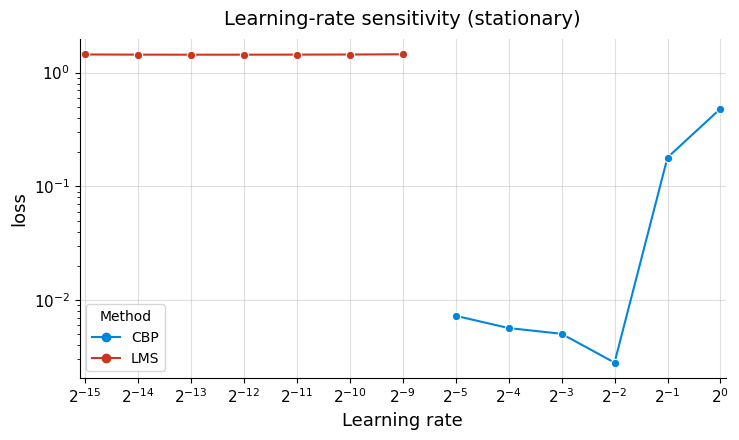

In [8]:
lr_sensitivity('01')

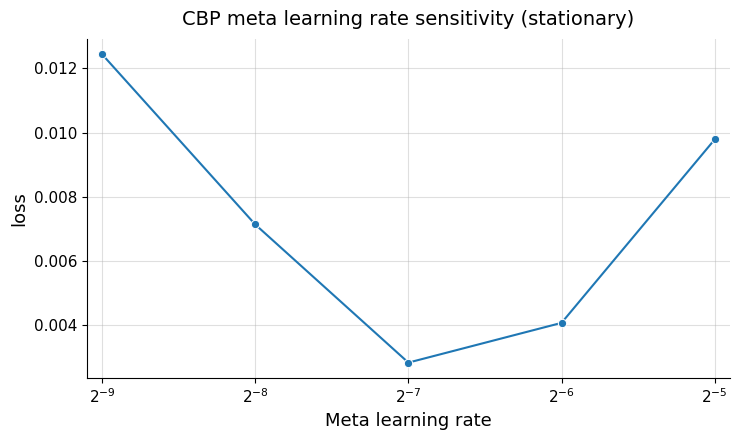

In [9]:
cbp_param_sensitivity('01', META_LR)

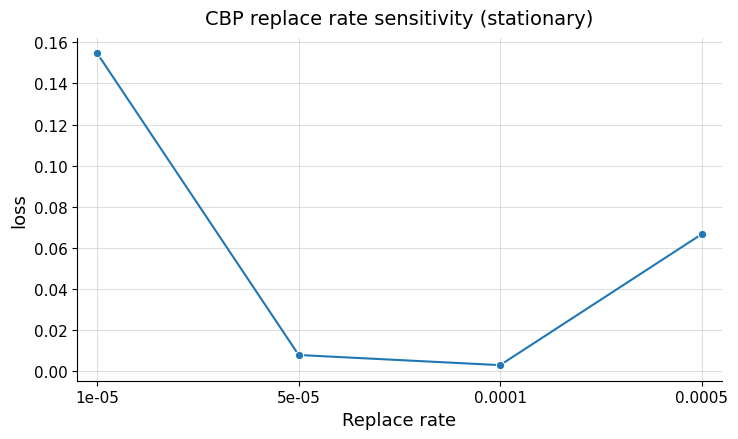

In [10]:
cbp_param_sensitivity('01', RR)

### 1.2 CBP learning curves by hyperparameter variant (5-seed, no CI)

The learning-curve equivalent of the sensitivity plots above: one curve per value of each
swept CBP hyperparameter (hue), with the other two held at baseline. Loss is on a log y-axis.

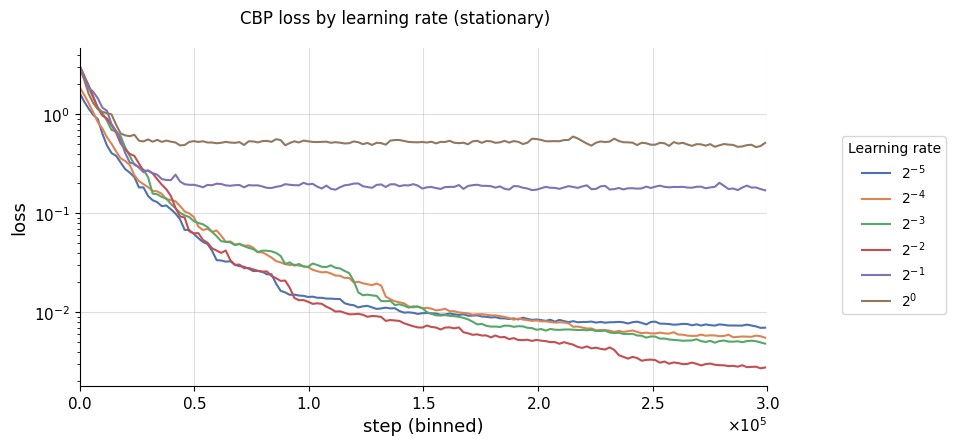

In [11]:
cbp_variant_curves('01', LR, logy=True)

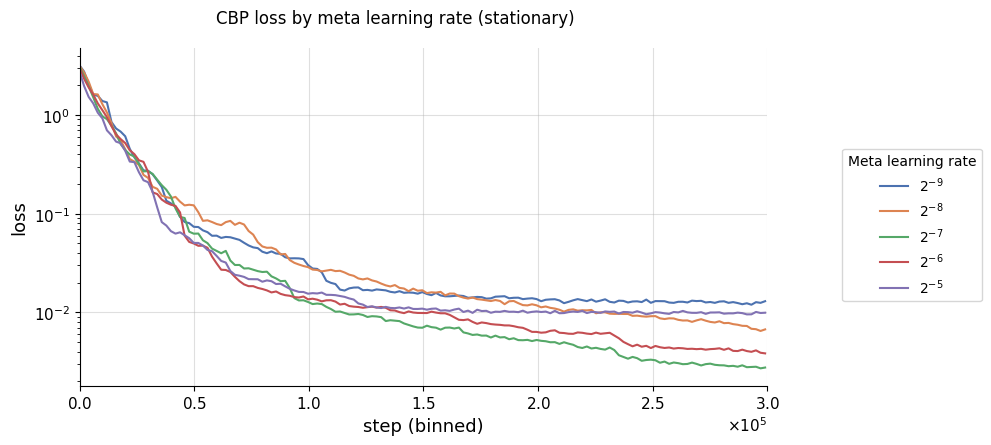

In [12]:
cbp_variant_curves('01', META_LR, logy=True)

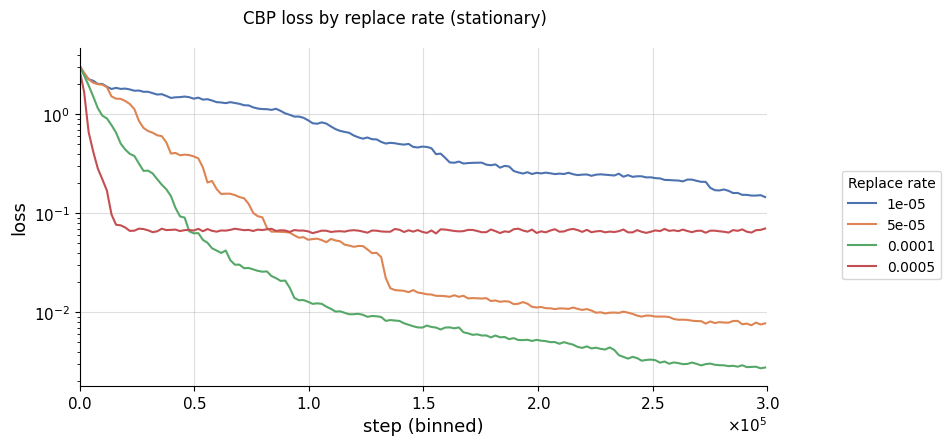

In [13]:
cbp_variant_curves('01', RR, logy=True)

### 1.3 Best-config learning curves (30 seeds, 95% CI)

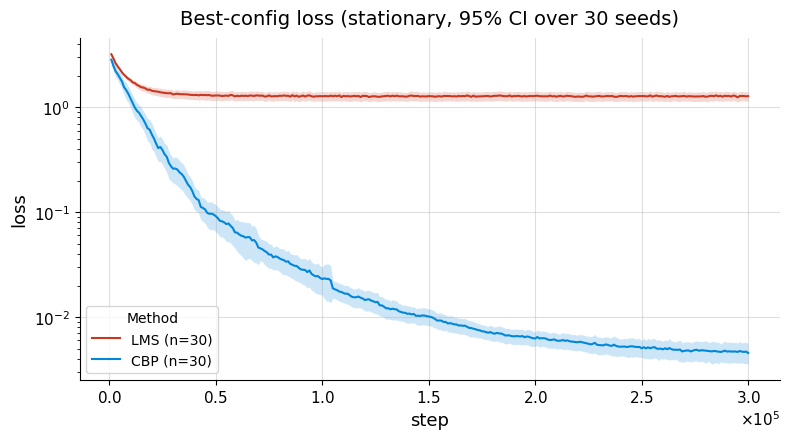

In [14]:
best_curves('01')

---
## 2. Non-stationary  (`task.flip_period = 100`)

### 2.1 Hyperparameter sensitivity (5-seed sweeps, no CI)

Same as 1.1 for the non-stationary task. LMS diverges at large step-sizes; those runs log a NaN
mean loss and appear as gaps (not omitted).

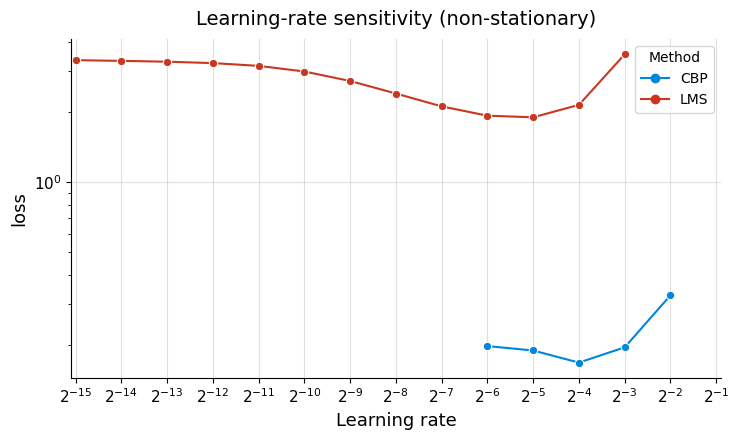

In [15]:
lr_sensitivity('02')

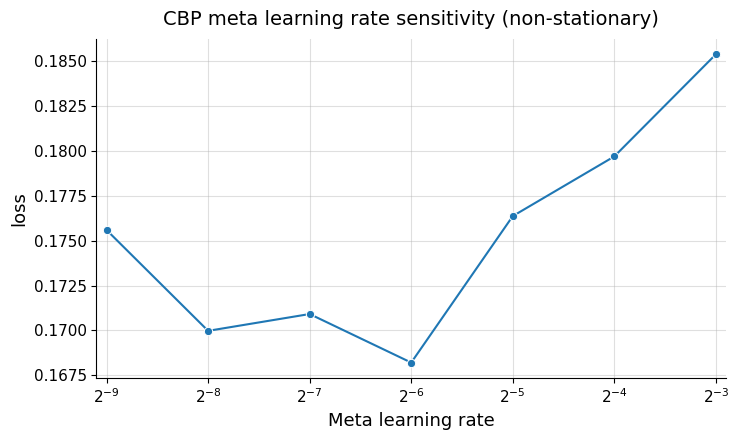

In [16]:
cbp_param_sensitivity('02', META_LR)

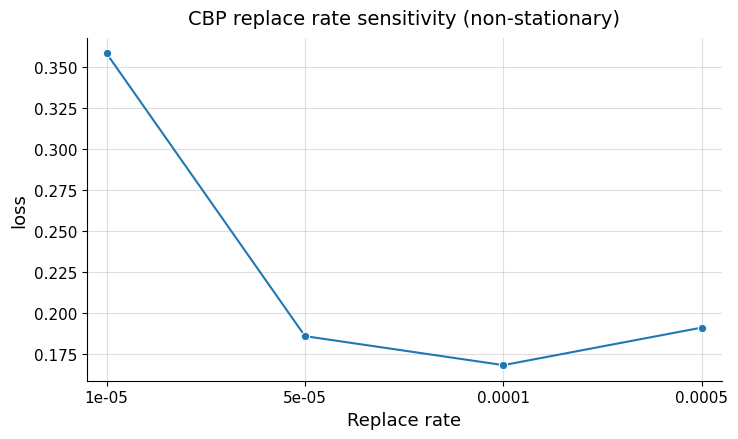

In [17]:
cbp_param_sensitivity('02', RR)

### 2.2 CBP learning curves by hyperparameter variant (5-seed, no CI)

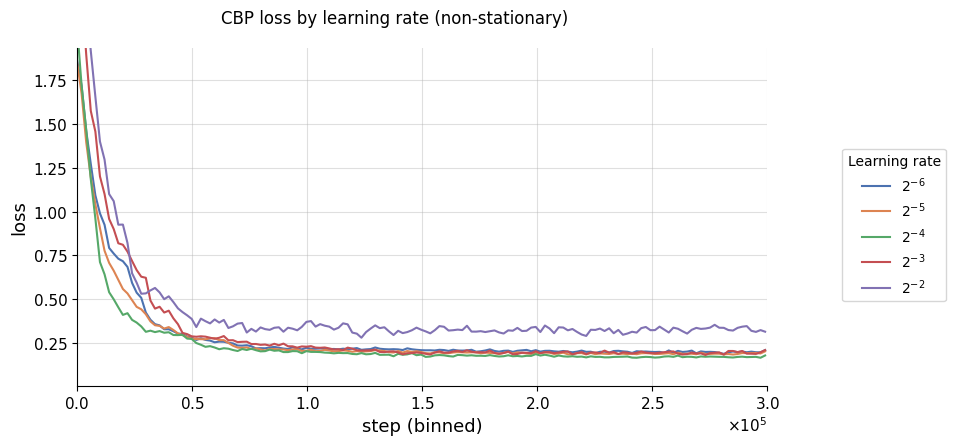

In [18]:
cbp_variant_curves('02', LR)

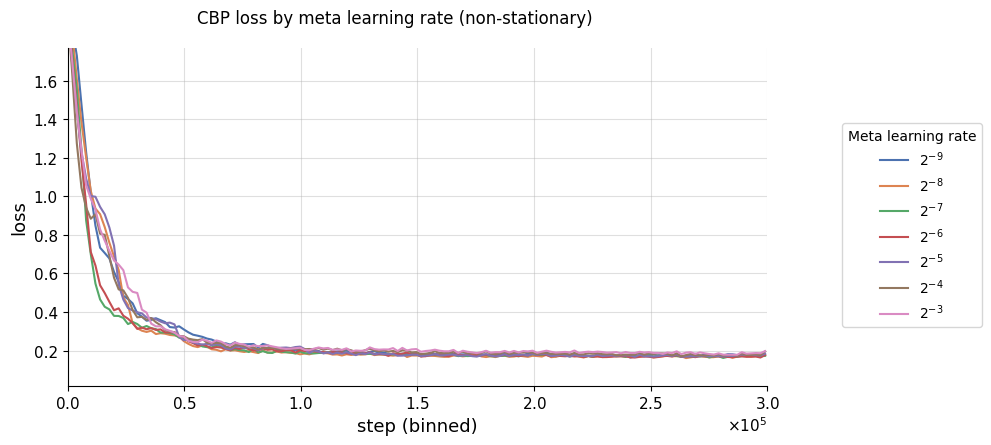

In [19]:
cbp_variant_curves('02', META_LR)

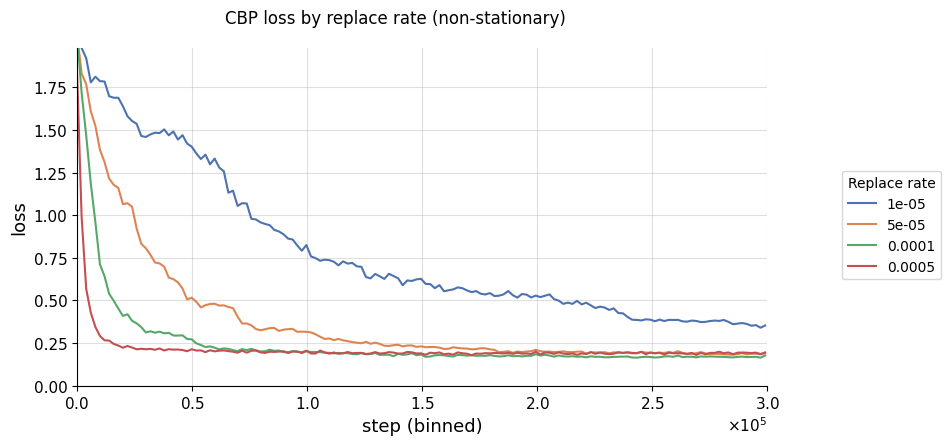

In [20]:
cbp_variant_curves('02', RR)

### 2.3 Best-config learning curves (30 seeds, 95% CI)

Note: at the time of writing, the 30-seed `cbp_autostep_ns` best-config run had not been logged
to `feature_sifting_best`, so only LMS appears below. Re-run
`02_nonstationary/best/cbp_autostep.yaml` to populate it.

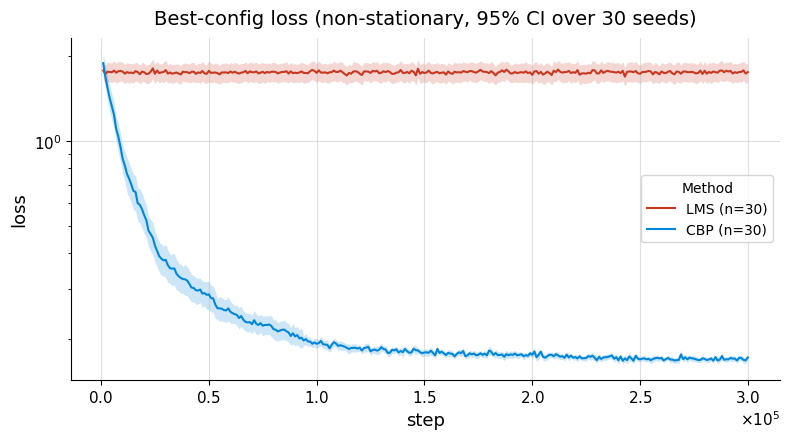

In [21]:
best_curves('02')

---
## 3. Noise floor — what does CBP converge to in the limit?

**Question.** Does CBP's continual generate-and-test eventually assemble the *right* feature set,
or does it stall?

**Noise floor.** The task logs `best_possible_noise` = Σ over the 10 target features of the
**lowest noise coefficient** among the learner's current candidates pointing at that target
(1.0 for a target with no candidate). It is the quality ceiling of CBP's current feature pool:
the cleanest features it currently holds, hence (a proxy for) the lowest loss it could reach
*given those features*. **Lower is better; 0 = every target has a perfectly clean candidate.**

**Hypothesis.** With a *fixed* pruning/replacement rate, CBP's noise floor should plateau
**above** the achievable minimum. As the pool improves, a freshly generated random feature is
increasingly unlikely to beat an already-good incumbent for its target, so the rate of genuine
improvement falls below the fixed rate at which slots are recycled — and progress stalls within
the training horizon. LMS never recycles (`prune_mask` is always False), so its noise floor is
flat at the initial value and serves as a static reference.

### 3.1 Noise floor of the best run (CBP, 30 seeds)

CBP lowers its noise floor over training, then flattens. The y-axis is zoomed to the tail so the
converged level — and its gap above the ideal of 0 (a perfectly clean feature for every target) —
is clearly visible. It settles around ~0.28, well short of 0.

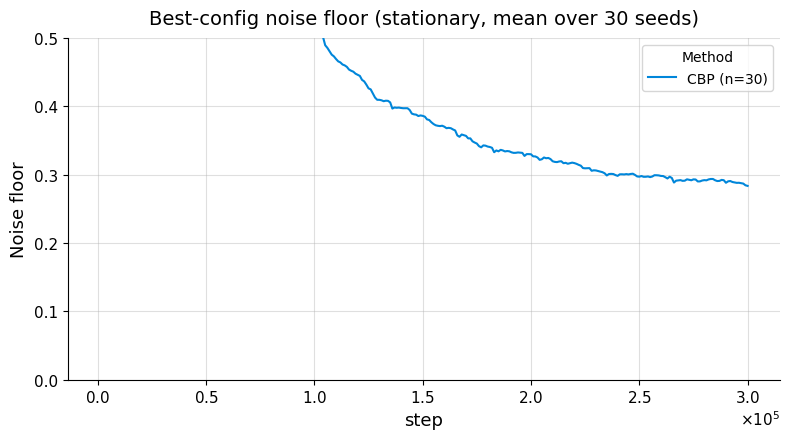

In [22]:
best_curves('01', y_col='best_possible_noise', y_label='Noise floor', logy=False, methods=['CBP'], ylim=(0, 0.5))

### 3.2 Noise floor vs. pruning rate (`replace_rate`)

`replace_rate` is the rate at which CBP recycles low-utility feature slots — i.e. the pruning
rate. If the *fixed rate* is what bottlenecks feature discovery, the asymptotic noise floor
should depend on it (a higher rate buys more generate-and-test attempts and reaches a lower
floor) rather than every rate collapsing to the same minimum — evidence that CBP does not
converge to the optimal feature set. (CBP sweep, 5 seeds, other params at baseline, no CI.)

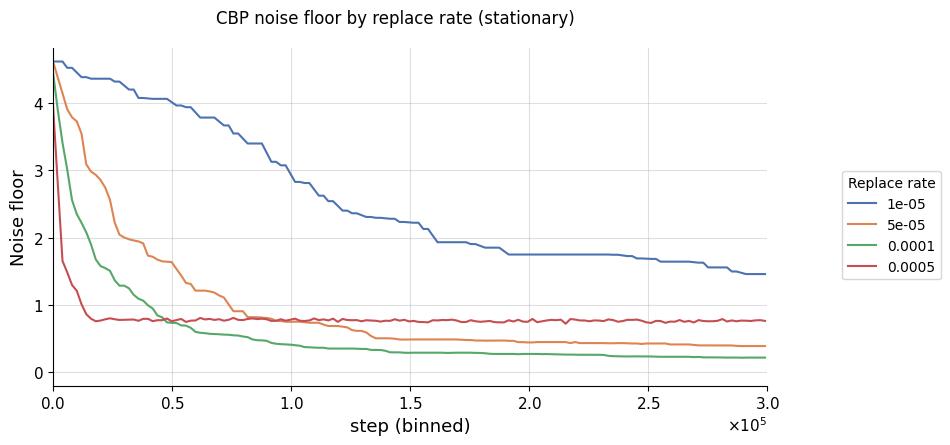

In [23]:
cbp_variant_curves('01', RR, y_col='best_possible_noise', y_label='Noise floor')

---
## 4. Noise-floor convergence — long-horizon `replace_rate` sweep

Long runs (**10M steps, 50 seeds**) sweeping the pruning rate `replace_rate` ∈ {2⁻¹⁶ … 2⁻¹⁰} on the
**stationary** task, with the other CBP hyperparameters fixed at the 01 stationary best
(`lr=2⁻²`, `meta_lr=2⁻⁷`). Goal: see whether the noise floor converges to a positive,
rate-dependent value or keeps decreasing toward 0.

Config: `conf/sweeps/algorithm_comparison/03_convergence/cbp_replace_rate.yaml`
(MLflow experiment `feature_sifting_convergence`). The cells below no-op with a message until that
sweep has been run and downloaded.

In [24]:
# Long-horizon convergence sweep — downloads + loads only if the experiment exists yet.
from phd.research_utils.scripts.mlflow_download import download_experiment

download_experiment('feature_sifting_convergence', output_dir='data')

conv_params = 'data/feature_sifting_convergence_params.csv'
if os.path.exists(conv_params):
    conv_cfg, conv_run = load_experiment_data(
        conv_params, 'data/feature_sifting_convergence_metrics.csv')
    drop_summary_rows(conv_run)
else:
    conv_cfg, conv_run = {}, {}
print('Convergence buckets:', {k: len(v) for k, v in conv_cfg.items()})

INFO:phd.research_utils.scripts.mlflow_download:Tracking URI: postgresql:///mlflow?host=/var/run/postgresql&port=5433
INFO:phd.research_utils.scripts.mlflow_download:Found experiment 'feature_sifting_convergence' (id=39)
INFO:phd.research_utils.scripts.mlflow_download:Found 8 runs
INFO:phd.research_utils.scripts.mlflow_download:Discovered 10 metric names from 8 sample runs
INFO:phd.research_utils.scripts.mlflow_download:Metrics to download: ['average_loss', 'best_possible_noise', 'final_loss', 'generated_best_frac', 'loss', 'loss_std', 'n_generated', 'n_pruned', 'normalized_loss', 'pruned_best_frac']
Downloading: 100%|██████████| 8/8 [00:15<00:00,  1.95s/it]
INFO:phd.research_utils.scripts.mlflow_download:Saved 8 param rows to data/feature_sifting_convergence_params.csv
INFO:phd.research_utils.scripts.mlflow_download:Saved 70007 metric rows to data/feature_sifting_convergence_metrics.csv
INFO:phd.research_utils.scripts.mlflow_download:8/8 runs saved successfully


Convergence buckets: {'cbp_replace_rate_v1': 7}


In [29]:
def _conv_sweep():
    """Latest convergence sweep as (cfg, run), prepped; (None, None) until it has been run."""
    cands = [k for k in conv_cfg if re.match(r'^cbp_replace_rate_v\d+$', k)]
    if not cands:
        return None, None
    sw = max(cands, key=lambda k: int(k.rsplit('_v', 1)[-1]))
    return prep_cfg(conv_cfg[sw]), conv_run[sw]


_NO_DATA = ('No convergence data yet — run '
            '03_convergence/cbp_replace_rate.yaml, then re-run the download cell above.')


def conv_noise_vs_steps(y_col='best_possible_noise', n_bins=300):
    """Noise floor vs. training step, one curve per replace_rate, log y-axis."""
    cfg, run = _conv_sweep()
    if cfg is None:
        print(_NO_DATA); return
    plot_learning_curves(
        run_df=run, config_df=cfg, n_bins=n_bins, figsize=(8, 4.5),
        y_col=y_col, y_label='Noise floor', hue_col=RR, legend_title='Replace rate',
        pow_2_legend=True, show_ci=False,
    )
    apply_logy()
    plt.suptitle('Noise floor vs. steps (stationary, 50 seeds, log y)')
    plt.tight_layout(); plt.show()


def conv_noise_vs_recycles(y_col='best_possible_noise', show_reference=True):
    """Noise floor vs. cumulative recycle events (log-log) — the natural clock for
    generate-and-test. Dashed line is the perfect-retention reference (~100/N: the running-minimum
    floor if no per-target best feature were ever pruned). Curves peeling above it indicate good
    features are being lost (churn) -> non-convergence to the optimal feature set."""
    cfg, run = _conv_sweep()
    if cfg is None:
        print(_NO_DATA); return
    rr_map = dict(zip(cfg['run_id'], cfg[RR]))
    rr_vals = sorted(cfg[RR].dropna().unique())
    colors = dict(zip(rr_vals, sns.color_palette('viridis', len(rr_vals))))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    all_N = []
    for rr in rr_vals:  # plot low -> high rate so the legend is ordered
        for rid in cfg.loc[cfg[RR] == rr, 'run_id']:
            g = run[run['run_id'] == rid].sort_values('step')
            if g.empty:
                continue
            N = g['n_pruned'].cumsum().to_numpy()      # cumulative recycles per seed
            y = g[y_col].to_numpy()
            m = np.isfinite(N) & np.isfinite(y) & (N > 0) & (y > 0)
            if not m.any():
                continue
            ax.plot(N[m], y[m], color=colors[rr],
                    label=f'$2^{{{int(np.round(np.log2(rr)))}}}$')
            all_N.append(N[m])
    if show_reference and all_N:
        Nc = np.concatenate(all_N)
        Nref = np.logspace(np.log10(Nc.min()), np.log10(Nc.max()), 100)
        ax.plot(Nref, 100.0 / Nref, 'k--', lw=1.5, label='~100/N (perfect retention)')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
    ax.set_xlabel('cumulative recycles (per seed)')
    ax.set_ylabel('Noise floor')
    ax.set_title('Noise floor vs. recycles (log-log, stationary, 50 seeds)')
    ax.legend(title='Replace rate', ncol=2, fontsize=8)
    plt.tight_layout()
    # ; plt.show()

### 4.1 Noise floor vs. steps (log y)

Does each rate's curve flatten within 10M steps?

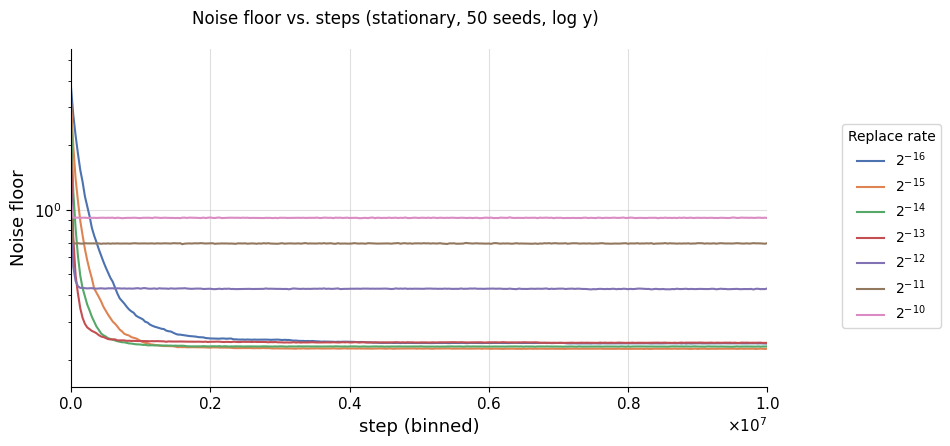

In [30]:
conv_noise_vs_steps()

### 4.2 Noise floor vs. cumulative recycles (log-log)

The natural clock for a generate-and-test process. The dashed `~100/N` line is the
perfect-retention reference (the running-minimum floor if no per-target best feature were ever
pruned, slope −1). Rate curves that **peel above it and flatten** are losing good features as fast
as they find better ones (churn) — i.e. CBP is **not** converging to the optimal feature set; a
curve that **tracks** the reference would instead be slowly heading to 0 (convergence, just slow).

(0.1, 10.0)

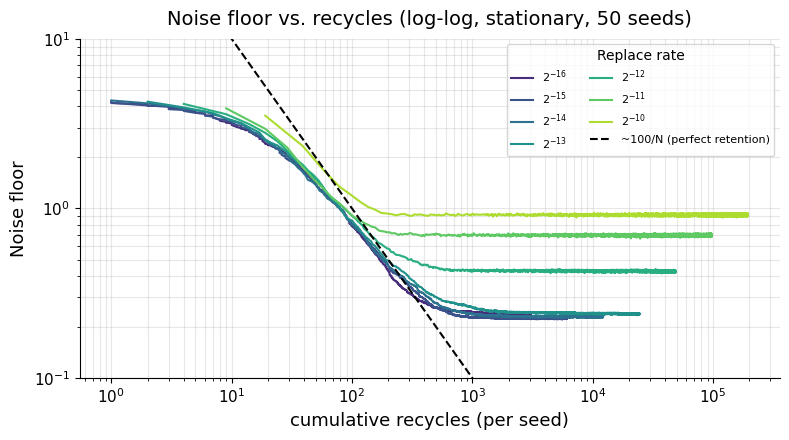

In [34]:
conv_noise_vs_recycles()
plt.ylim(0.1, 10.0)